# Chip Purchasing Behavior Analysis

In [1]:
# Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from scipy import stats

# Load the data 

In [2]:
transaction_df = pd.read_excel("QVI_transaction_data.xlsx") # For this I installed Openxyl to load excel
customer_df = pd.read_csv("QVI_purchase_behaviour.csv") 

In [3]:
# Convert Excel integer dates to Python datetime objects
# origin='1899-12-30' is the standard baseline for Excel files
transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], unit='D', origin='1899-12-30')

# Quality Check: Ensure the conversion worked
print(f"Date range: {transaction_df['DATE'].min()} to {transaction_df['DATE'].max()}")

Date range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00


# Data Cleaning & Preparation

### Check the data structures

In [4]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [5]:
# Summary statistics - shows outliers
transaction_df.describe() 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [6]:
transaction_df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


### Data format corrections - Date Conversion

- Excel stores dates as serial day counts using a legacy calendar that includes the incorrect treatment of 1900 as a leap year. To ensure accurate conversion, the Excel origin date of 1899-12-30 was used.

- Transaction dates were stored as Excel serial integers and were converted to datetime format using the Excel origin date to enable accurate time-based analysis.

### Examine Product Names

In [7]:
transaction_df['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [8]:
transaction_df['PROD_NAME'].value_counts()

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
                                            ... 
RRD Pc Sea Salt     165g                    1431
Woolworths Medium   Salsa 300g              1430
NCC Sour Cream &    Garden Chives 175g      1419
French Fries Potato Chips 175g              1418
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

##### Insight

From the business question, scope is defined-Chips only. Anything logically not, is to be excluded -dips,odd/non-snack items, 

Mostly chips will have repeating brands, flavours, weights...odd ones are our suspects.

#### Text Analysis - Splitting Product Names into Words

In [9]:
product_words = pd.DataFrame({
    'words': ' '.join(transaction_df['PROD_NAME'].unique()).split()
})

#### Removing Digits and Special Characters

In [10]:
# Remove words with digits
product_words = product_words[~product_words['words'].str.contains(r'\d', regex=True)] #not words

In [11]:
# Remove words with special characters
product_words = product_words[product_words['words'].str.match(r'^[a-zA-Z]+$', na=False)]

In [12]:
# Count frequency and sort
word_counts = product_words['words'].value_counts().reset_index()
word_counts.columns = ['words', 'count']
word_counts.head()

,words,count
0,Chips,21
1,Smiths,16
2,Crinkle,14
3,Cut,14
4,Kettle,13


### Removing irrelevant Products - Salsa products

In [13]:
# Checking for Salsa Products in a new col
transaction_df['SALSA'] = transaction_df['PROD_NAME'].str.lower().str.contains('salsa')

In [14]:
# Remove salsa products from the dataset
transaction_df = transaction_df[transaction_df['SALSA'] == False].copy()  #removes salsa records
transaction_df = transaction_df.drop('SALSA', axis=1)

### Handle outliers

In [15]:
# In transaction summary stats - 200 units was an outlier
transaction_df[transaction_df['PROD_QTY'] == 200] 

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [16]:
#Filtering Out the Customer
transaction_df = transaction_df[transaction_df['LYLTY_CARD_NBR'] != 226000].copy() # drop the above 2 rows

### Insight

To ensure the analysis focused solely on chips, product names were explored to identify and exclude non-chip items such as salsa & dips

In [17]:
#Insight after removal of salsa
print(f"Original dataset: 264,836 rows")

print(f"After removing salsa: {len(transaction_df)} rows")
print(f"Rows removed: 18,094 salsa products + 2 outliers = 18,096 total")

Original dataset: 264,836 rows
After removing salsa: 246740 rows
Rows removed: 18,094 salsa products + 2 outliers = 18,096 total


## Counting Transactions by Date

In [18]:
#Counting Transactions by Date
transactions_by_day = transaction_df.groupby('DATE').size().reset_index(name='N')
transactions_by_day.head()

,DATE,N
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660


## Creating Date Sequence

A date sequence is a complete list of consecutive dates with no gaps. For visibility in the plots. We can capture 0_transaction days.

In [19]:
#Creating Date Sequence all 365 days/12months
all_dates = pd.DataFrame({
    'DATE': pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')
})
all_dates.tail()

,DATE
360,2019-06-26
361,2019-06-27
362,2019-06-28
363,2019-06-29
364,2019-06-30


In [20]:
# Merge the dates with transaction by day
transactions_by_day = all_dates.merge(transactions_by_day, on='DATE', how='left')
transactions_by_day['N'] = transactions_by_day['N'].fillna(0)

# which day had zero transactions?
transactions_by_day[transactions_by_day['N'] == 0]

,DATE,N
177,2018-12-25,0.0


## Insight: Customer behavior pattern

December 25 was the only day with zero transactions in the entire year.

This confirms that stores follow expected holiday closures, and validates 
our data quality - no transactions doesn't mean missing data, it means stores were genuinely closed. 

Additionally, we see a 28% spike in sales during the week leading up to Christmas (Dec 18-24), suggesting customers stock up before the holiday closure.



- Dec 24 spike (853 txns) = customers planning ahead
- Dec 25 zero txns = store closure
- Dec 26 normal levels (700 txns) = demand returns immediately


### Recommendation
EXTEND PRE-CHRISTMAS HOURS:
- Dec 23-24: Additional 4-5 operating hours
- Captures last-minute shoppers effectively

### Innovation Opportunity (Longer-term)
Explore 24/7 vending solutions in high-traffic locations for 
convenient purchases during closure periods.

# Visualization - Plot transactions by day

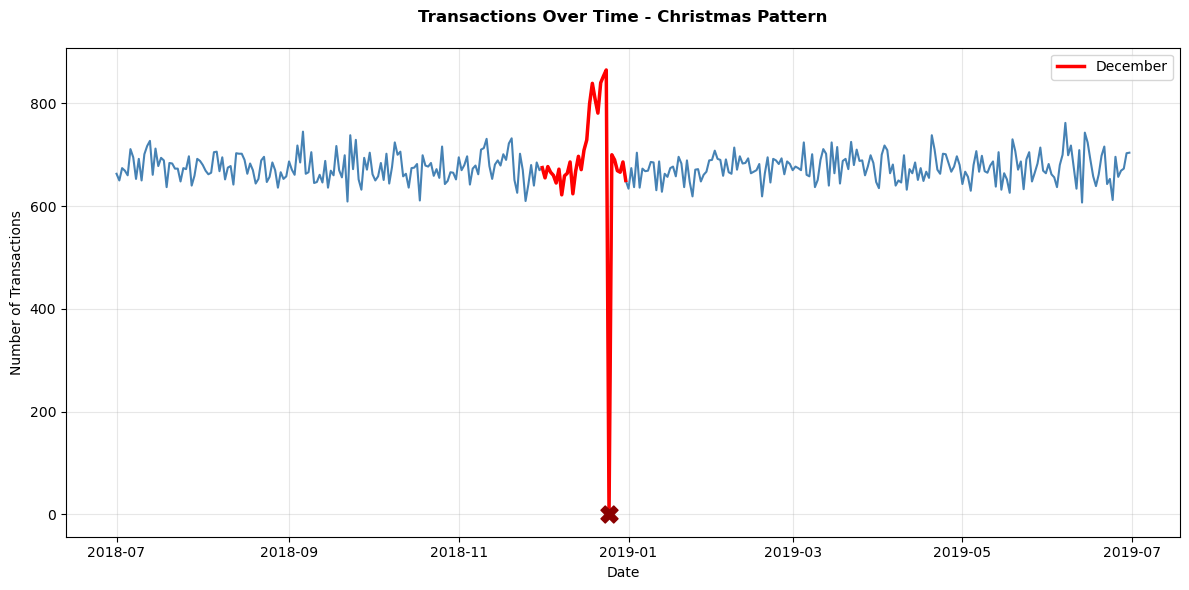

In [21]:
# Christmas pattern visualization
plt.figure(figsize=(12, 6))

# Plot all transactions
plt.plot(transactions_by_day['DATE'], transactions_by_day['N'], 
         color='steelblue', linewidth=1.5)

# Filter for December
dec_data = transactions_by_day[transactions_by_day['DATE'].dt.month == 12]
plt.plot(dec_data['DATE'], dec_data['N'], 
         color='red', linewidth=2.5, label='December')

# Mark Christmas Day
christmas = transactions_by_day[transactions_by_day['DATE'] == '2018-12-25']
plt.scatter(christmas['DATE'], christmas['N'], 
           color='darkred', s=150, zorder=5, marker='X')
# Plot
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions Over Time - Christmas Pattern\n', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### December sales

In [22]:
# Filtering to December sales
transactions_by_day[transactions_by_day['DATE'].dt.month == 12]


,DATE,N
153,2018-12-01,675.0
154,2018-12-02,655.0
155,2018-12-03,677.0
156,2018-12-04,666.0
157,2018-12-05,660.0
158,2018-12-06,645.0
159,2018-12-07,672.0
160,2018-12-08,622.0
161,2018-12-09,659.0
162,2018-12-10,664.0


In [23]:
print("\n📊 KEY FINDING:")
print("December shows increased sales leading up to Christmas (Dec 18-24)")
print("Zero transactions on Christmas Day (Dec 25) - stores closed")
print("Sales return to normal patterns after Dec 26")


📊 KEY FINDING:
December shows increased sales leading up to Christmas (Dec 18-24)
Zero transactions on Christmas Day (Dec 25) - stores closed
Sales return to normal patterns after Dec 26


## Pack Size Extraction

In [24]:
# Extracting Pack Size
transaction_df['PACK_SIZE'] = transaction_df['PROD_NAME'].str.extract(r'(\d+)')[0].astype(float)
transaction_df.groupby('PACK_SIZE').size().sort_index(ascending=False)

PACK_SIZE
380.0     6416
330.0    12540
270.0     6285
250.0     3169
220.0     1564
210.0     6272
200.0     4473
190.0     2995
180.0     1468
175.0    66390
170.0    19983
165.0    15297
160.0     2970
150.0    40203
135.0     3257
134.0    25102
125.0     1454
110.0    22387
90.0      3008
70.0      1507
dtype: int64

In [25]:
# OR sort by count (descending)
transaction_df.groupby('PACK_SIZE').size().sort_values(ascending=False)

PACK_SIZE
175.0    66390
150.0    40203
134.0    25102
110.0    22387
170.0    19983
165.0    15297
330.0    12540
380.0     6416
270.0     6285
210.0     6272
200.0     4473
135.0     3257
250.0     3169
90.0      3008
190.0     2995
160.0     2970
220.0     1564
70.0      1507
180.0     1468
125.0     1454
dtype: int64

## Visualization - Histogram: Pack size distribution

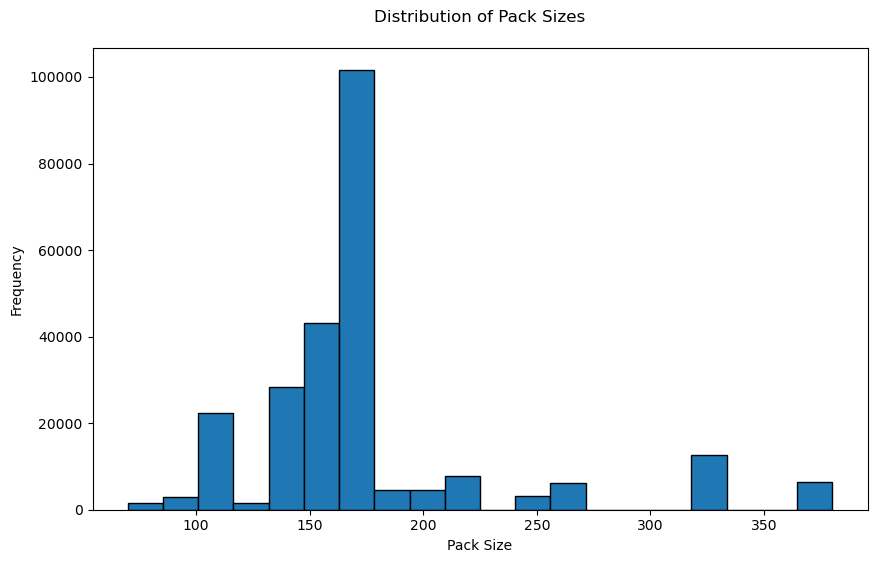

In [26]:
#Plot 
plt.figure(figsize=(10, 6))
plt.hist(transaction_df['PACK_SIZE'], bins=20, edgecolor='black')
plt.xlabel('Pack Size')
plt.ylabel('Frequency')
plt.title('Distribution of Pack Sizes\n')
plt.show()

## Brand Names extraction

In [27]:
# Extracting Brand Names
transaction_df['BRAND'] = transaction_df['PROD_NAME'].str.split().str[0].str.upper()
transaction_df['BRAND'].describe()

count     246740
unique        28
top       KETTLE
freq       41288
Name: BRAND, dtype: object

### Cleaning Brand Names - using replace()

In [28]:
# Instead of RED use RRD then check unique brands
transaction_df['BRAND'] = transaction_df['BRAND'].replace('RED', 'RRD')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('NCC', 'NATURAL')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('SMITH', 'SMITHS')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('DORITO', 'DORITOS')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('INFZNS', 'INFUZIONS')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('GRNWVES', 'GRAIN')
transaction_df['BRAND'] = transaction_df['BRAND'].replace('SNBTS', 'SUNBITES')
transaction_df['BRAND'].unique()

array(['NATURAL', 'CCS', 'SMITHS', 'KETTLE', 'GRAIN', 'DORITOS',
       'TWISTIES', 'WW', 'THINS', 'BURGER', 'CHEEZELS', 'INFUZIONS',
       'RRD', 'PRINGLES', 'TYRRELLS', 'COBS', 'FRENCH', 'TOSTITOS',
       'CHEETOS', 'WOOLWORTHS', 'SUNBITES'], dtype=object)

In [29]:
# Find out what's inside BRAND col any calculations
transaction_df['BRAND'].value_counts()

BRAND
KETTLE        41288
SMITHS        30353
DORITOS       25224
PRINGLES      25102
RRD           16321
INFUZIONS     14201
THINS         14075
WW            10320
COBS           9693
TOSTITOS       9471
TWISTIES       9454
GRAIN          7740
NATURAL        7469
TYRRELLS       6442
CHEEZELS       4603
CCS            4551
SUNBITES       3008
CHEETOS        2927
BURGER         1564
WOOLWORTHS     1516
FRENCH         1418
Name: count, dtype: int64

## Explore customer data Features further before merging

In [30]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [31]:
customer_df.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [32]:
customer_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [33]:
# Check unique identifiers 
customer_df['LYLTY_CARD_NBR'].nunique()  # it is = records

72637

### Insight

This means that every record/row is unique.

In [34]:
# Lifestage - customer segmentation by age, family stage
customer_df['LIFESTAGE'].value_counts(dropna=False) #checks unique values

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [35]:
# Check out the 3rd col Premium customer
customer_df['PREMIUM_CUSTOMER'].value_counts(dropna=False) #checks unique values

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

# Merge Data

In [36]:
# merging on a specific column
merged_data = transaction_df.merge(customer_df, on='LYLTY_CARD_NBR', how='left', validate='many_to_one')
merged_data.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget


In [37]:
# Check for Nulls After Merge
merged_data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [38]:
# Save the merged data
merged_data.to_csv('retail_data_merged.csv', index=False)

In [39]:
# Summary statistics by segment
merged_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000,246740.000000
mean,2018-12-30 01:18:58.448569344,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113,175.583521
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897,59.432118


## Total Sales by Segments

In [40]:
# Total sales generated by specific customer segments
sales = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index(name='SALES')
sales

,LIFESTAGE,PREMIUM_CUSTOMER,SALES
0,MIDAGE SINGLES/COUPLES,Budget,33345.70
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25
2,MIDAGE SINGLES/COUPLES,Premium,54443.85
3,NEW FAMILIES,Budget,20607.45
4,NEW FAMILIES,Mainstream,15979.70
5,NEW FAMILIES,Premium,10760.80
6,OLDER FAMILIES,Budget,156863.75
7,OLDER FAMILIES,Mainstream,96413.55
8,OLDER FAMILIES,Premium,75242.60
9,OLDER SINGLES/COUPLES,Budget,127833.60


<Figure size 1200x600 with 0 Axes>

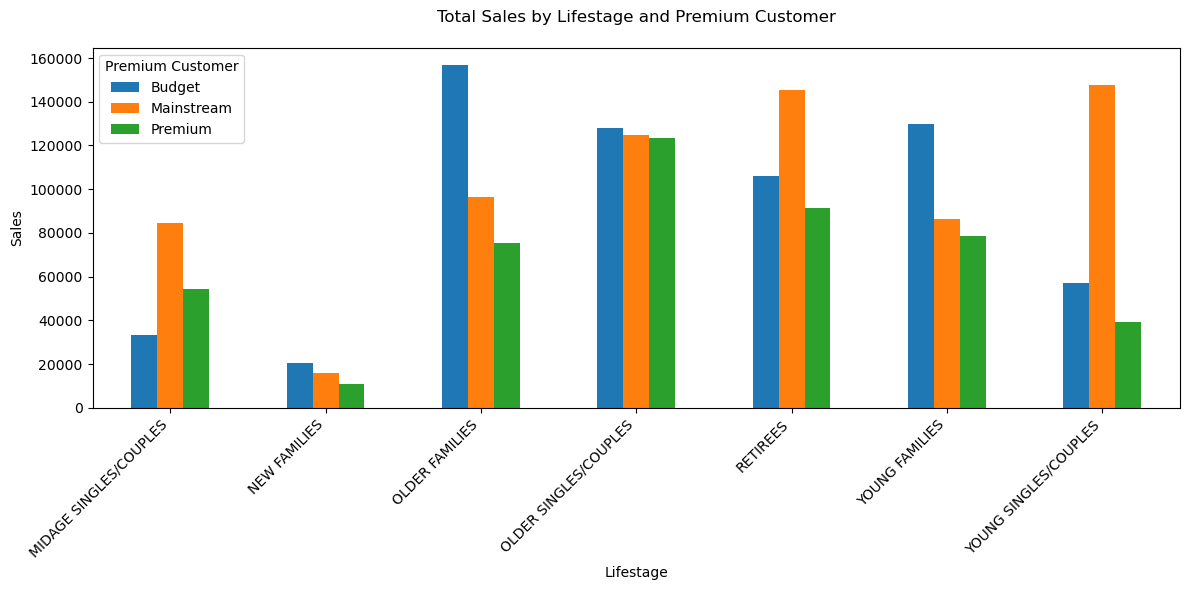

In [41]:
#Plot total sales by segments
plt.figure(figsize=(12, 6))
sales_pivot = sales.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='SALES')
sales_pivot.plot(kind='bar', figsize=(12, 6))         # Pivot works well for segment analysis & patterns

plt.ylabel('Sales')
plt.xlabel('Lifestage')
plt.title('Total Sales by Lifestage and Premium Customer\n')
plt.xticks(rotation=45, ha='right') #horizontal alignments
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

### Number of customers per segment

In [42]:
# Number of Customers by Segments
customers = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index(name='CUSTOMERS')
customers.sort_values('CUSTOMERS', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,CUSTOMERS
19,YOUNG SINGLES/COUPLES,Mainstream,7917
13,RETIREES,Mainstream,6358
10,OLDER SINGLES/COUPLES,Mainstream,4858
9,OLDER SINGLES/COUPLES,Budget,4849
11,OLDER SINGLES/COUPLES,Premium,4682
6,OLDER FAMILIES,Budget,4611
12,RETIREES,Budget,4385
15,YOUNG FAMILIES,Budget,3953
14,RETIREES,Premium,3812
18,YOUNG SINGLES/COUPLES,Budget,3647


<Figure size 1200x600 with 0 Axes>

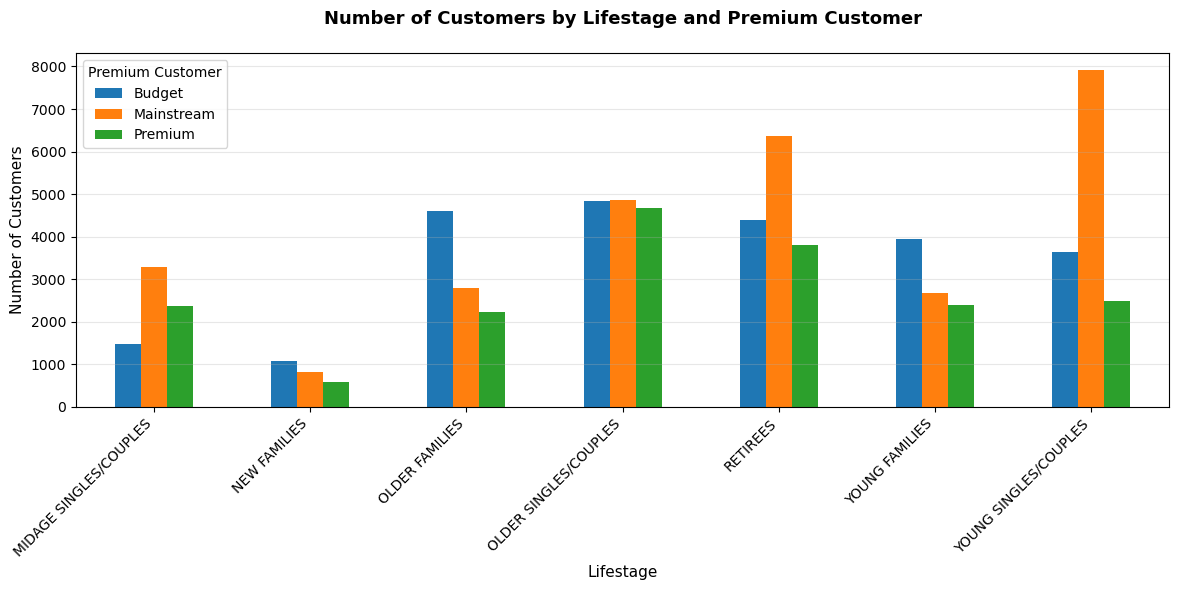

In [43]:
# Plot number of customers by segments
# Pivot works well for segment analysis & patterns

# Create pivot for easier plotting
customers_pivot = customers.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='CUSTOMERS')

# Plot
plt.figure(figsize=(12, 6))
customers_pivot.plot(kind='bar', figsize=(12, 6))

plt.xlabel('Lifestage', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.title('Number of Customers by Lifestage and Premium Customer\n', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer', title_fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Average Units per Customer Segment

In [44]:
# Calculate the average of QTY- Units per Segment
avg_units = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_qty=('PROD_QTY', 'sum'),
    unique_customers=('LYLTY_CARD_NBR', 'nunique')
).reset_index()

# Create a new col , AVG
avg_units['AVG'] = avg_units['total_qty'] / avg_units['unique_customers']

#Sort in DESC order
avg_units.sort_values('AVG', ascending=False)


,LIFESTAGE,PREMIUM_CUSTOMER,total_qty,unique_customers,AVG
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
6,OLDER FAMILIES,Budget,41853,4611,9.076773
8,OLDER FAMILIES,Premium,20239,2231,9.071717
15,YOUNG FAMILIES,Budget,34482,3953,8.722995
17,YOUNG FAMILIES,Premium,20901,2398,8.716013
16,YOUNG FAMILIES,Mainstream,23194,2685,8.638361
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398
11,OLDER SINGLES/COUPLES,Premium,31695,4682,6.769543
10,OLDER SINGLES/COUPLES,Mainstream,32607,4858,6.712021
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080


<Figure size 1200x600 with 0 Axes>

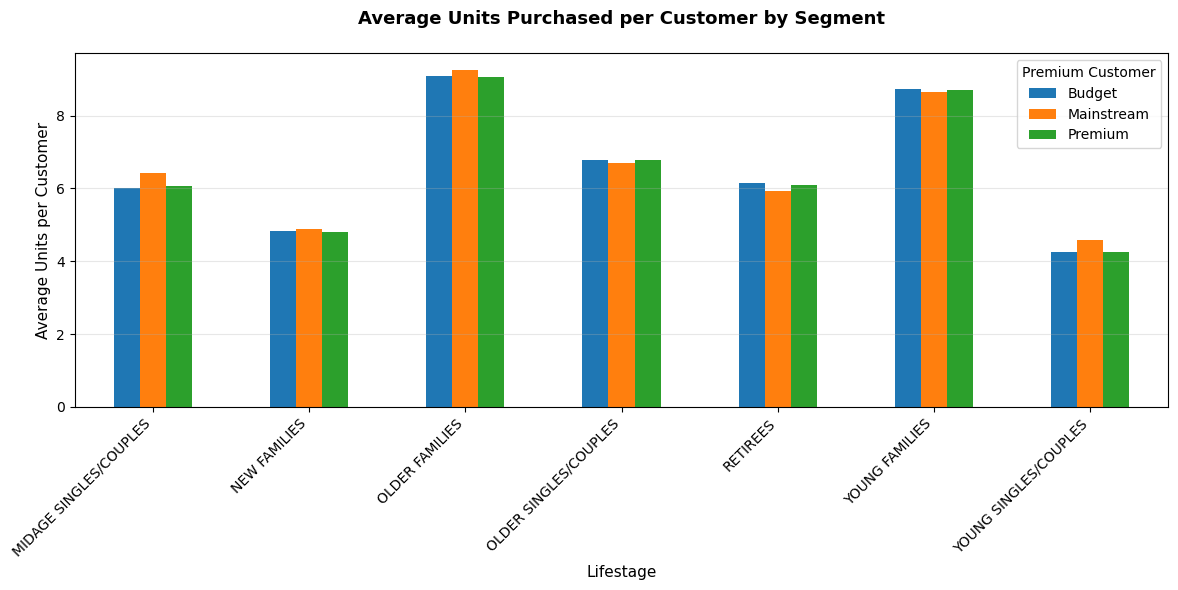

In [45]:
# Plot average units per segment

# Create pivot for plotting
avg_units_pivot = avg_units.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='AVG')

# Plot
plt.figure(figsize=(12, 6))
avg_units_pivot.plot(kind='bar', figsize=(12, 6))

plt.xlabel('Lifestage', fontsize=11)
plt.ylabel('Average Units per Customer', fontsize=11)
plt.title('Average Units Purchased per Customer by Segment\n', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer', title_fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Rank segments by sales

In [46]:
top_segments = sales.sort_values('SALES', ascending=False)
top_segments.head(3)

,LIFESTAGE,PREMIUM_CUSTOMER,SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95


## Brand affinity

###  Simply how much more (or less) a specific customer segment prefers a brand compared to the general population.

In [47]:
# Define target segment
target_segment = merged_data[
    (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
    (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')
]

print(f"\n📊 Target Segment: Mainstream Young Singles/Couples")
print(f" Total transactions: {len(target_segment):,}")
print(f" Unique customers: {target_segment['LYLTY_CARD_NBR'].nunique():,}")



📊 Target Segment: Mainstream Young Singles/Couples
 Total transactions: 19,544
 Unique customers: 7,917


In [48]:
# Brand purchases by target segment
target_brands = target_segment.groupby('BRAND').size().reset_index(name='target_purchases')

target_brands.head()

,BRAND,target_purchases
0,BURGER,62
1,CCS,222
2,CHEETOS,166
3,CHEEZELS,346
4,COBS,864


In [49]:
# Brand purchases by overall population
all_brands = merged_data.groupby('BRAND').size().reset_index(name='total_purchases')
all_brands.head()

,BRAND,total_purchases
0,BURGER,1564
1,CCS,4551
2,CHEETOS,2927
3,CHEEZELS,4603
4,COBS,9693


In [50]:
# Merge the two brand datasets
brand_affinity = target_brands.merge(all_brands, on='BRAND', how='inner')

brand_affinity

,BRAND,target_purchases,total_purchases
0,BURGER,62,1564
1,CCS,222,4551
2,CHEETOS,166,2927
3,CHEEZELS,346,4603
4,COBS,864,9693
5,DORITOS,2379,25224
6,FRENCH,78,1418
7,GRAIN,646,7740
8,INFUZIONS,1250,14201
9,KETTLE,3844,41288


In [51]:
# Calculate percentages
brand_affinity['target_pct'] = (brand_affinity['target_purchases'] / len(target_segment)) * 100
brand_affinity['total_pct'] = (brand_affinity['total_purchases'] / len(merged_data)) * 100

In [52]:
# Calculate affinity index
brand_affinity['affinity_index'] = (brand_affinity['target_pct'] / brand_affinity['total_pct']) * 100

# Sort by affinity index
brand_affinity = brand_affinity.sort_values('affinity_index', ascending=False)


In [53]:
# Display results
print("\n" + "="*70)
print("BRAND AFFINITY INDEX")
print("="*70)
print("Index > 100 = Over-indexed (segment prefers this brand)")
print("Index = 100 = Average preference")
print("Index < 100 = Under-indexed (segment avoids this brand)\n")

print(brand_affinity[['BRAND', 'target_purchases', 'affinity_index']].head(15).to_string(index=False))



BRAND AFFINITY INDEX
Index > 100 = Over-indexed (segment prefers this brand)
Index = 100 = Average preference
Index < 100 = Under-indexed (segment avoids this brand)

    BRAND  target_purchases  affinity_index
 TYRRELLS               619      121.309841
 TWISTIES               900      120.185761
  DORITOS              2379      119.071162
 TOSTITOS               890      118.637033
   KETTLE              3844      117.539987
 PRINGLES              2315      116.431040
     COBS               864      112.533451
INFUZIONS              1250      111.126386
    GRAIN               646      105.370166
    THINS              1166      104.586650
 CHEEZELS               346       94.898911
   SMITHS              1921       79.900933
  CHEETOS               166       71.599744
   FRENCH                78       69.445559
      RRD               875       67.684215


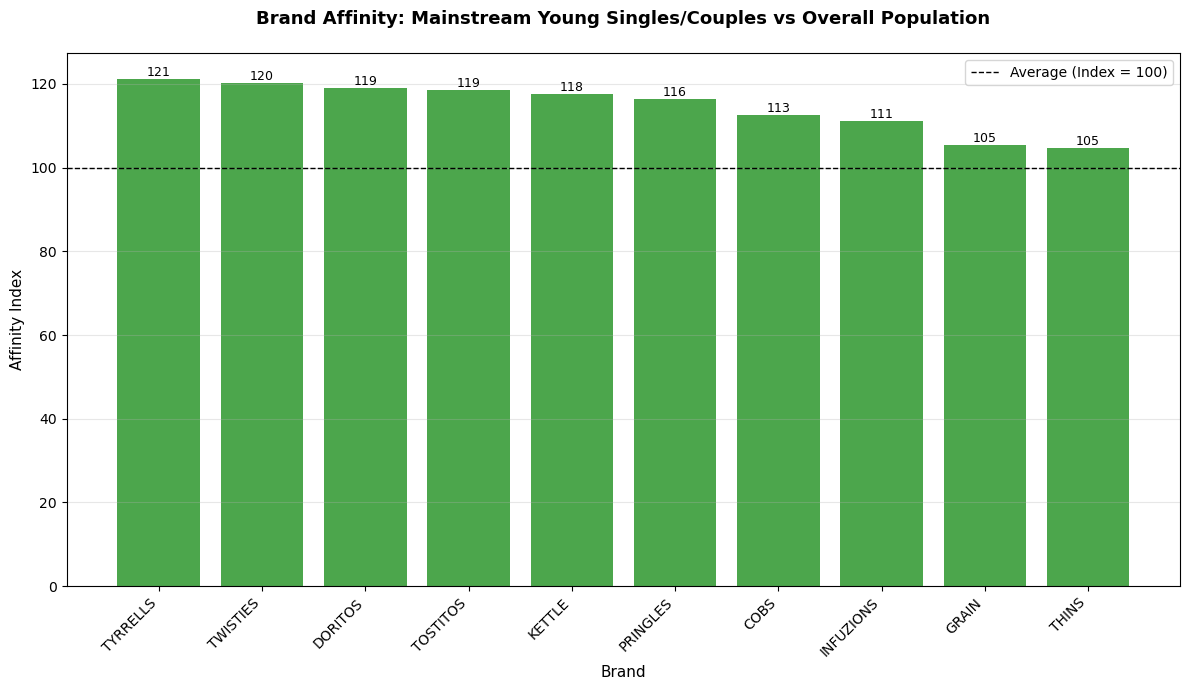

In [54]:
# Plot top 10 brands by affinity
plt.figure(figsize=(12, 7))

top_affinity = brand_affinity.head(10)

# Color bars based on affinity (>100 = green, <100 = red)
colors = ['green' if x > 100 else 'red' for x in top_affinity['affinity_index']]

bars = plt.bar(top_affinity['BRAND'], top_affinity['affinity_index'], color=colors, alpha=0.7)

# Add reference line at 100 (average)
plt.axhline(y=100, color='black', linestyle='--', linewidth=1, label='Average (Index = 100)')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}',
            ha='center', va='bottom', fontsize=9)

plt.xlabel('Brand', fontsize=11)
plt.ylabel('Affinity Index', fontsize=11)
plt.title('Brand Affinity: Mainstream Young Singles/Couples vs Overall Population\n', 
         fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [55]:
# Most preferred brand
top_brand = brand_affinity.iloc[0]
print(f"\nMOST PREFERRED BRAND:")
print(f"   {top_brand['BRAND']}")
print(f"   Affinity Index: {top_brand['affinity_index']:.0f}")
print(f"   Target segment is {top_brand['affinity_index']/100:.1f}x more likely to buy this brand")


MOST PREFERRED BRAND:
   TYRRELLS
   Affinity Index: 121
   Target segment is 1.2x more likely to buy this brand


In [56]:
# Most popular by raw numbers
most_purchased = brand_affinity.sort_values('target_purchases', ascending=False).head(5)
print(f"\nTOP 5 BRANDS BY PURCHASE VOLUME (Target Segment):")
for idx, row in most_purchased.iterrows():
    pct = (row['target_purchases'] / len(target_segment)) * 100
    print(f"   • {row['BRAND']}: {row['target_purchases']:,} purchases ({pct:.1f}% of segment)")



TOP 5 BRANDS BY PURCHASE VOLUME (Target Segment):
   • KETTLE: 3,844 purchases (19.7% of segment)
   • DORITOS: 2,379 purchases (12.2% of segment)
   • PRINGLES: 2,315 purchases (11.8% of segment)
   • SMITHS: 1,921 purchases (9.8% of segment)
   • INFUZIONS: 1,250 purchases (6.4% of segment)


## All segments

In [57]:
pip install streamlit pandas plotly

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: streamlit in c:\users\administrator\miniconda3\envs\dataenv\lib\site-packages (1.53.1)



In [58]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load YOUR Quantium data
@st.cache_data
def load_data():
    df = pd.read_csv('retail_data_merged.csv')  # Your cleaned CSV
    df['DATE'] = pd.to_datetime(df['DATE'])
    df['MONTH'] = df['DATE'].dt.month_name()
    df['YEAR_MONTH'] = df['DATE'].dt.to_period('M')
    return df

st.set_page_config(page_title="Chip Sales Performance", layout="wide", page_icon="💰")

st.title("Chip Sales Performance Dashboard")
st.markdown("**Total Revenue | Top Products | Best Customers | MoM Trends | Insights**")

df = load_data()

# TOTAL REVENUE KPI (Top Row)
col1, col2, col3, col4 = st.columns(4)
total_rev = df['TOT_SALES'].sum()
avg_order = df['TOT_SALES'].mean()
txn_count = len(df)
growth_mom = ((df.groupby('YEAR_MONTH')['TOT_SALES'].sum().iloc[-1] / 
               df.groupby('YEAR_MONTH')['TOT_SALES'].sum().iloc[-2] - 1) * 100).round(1)

with col1:
    st.metric("Total Revenue", f"${total_rev:,.0f}", delta=f"+{growth_mom}% MoM")
with col2:
    st.metric("Transactions", f"{txn_count:,}")
with col3:
    st.metric("Avg Order Value", f"${avg_order:.2f}")
with col4:
    st.metric("Best Month", df.groupby('MONTH')['TOT_SALES'].sum().idxmax())

# Sidebar Filters
st.sidebar.header("Filters")
month_filter = st.sidebar.multiselect("Months", df['MONTH'].unique(), default=df['MONTH'].unique())
premium_filter = st.sidebar.multiselect("Customer Type", df['PREMIUM_CUSTOMER'].unique(), default=df['PREMIUM_CUSTOMER'].unique())

filtered_df = df[
    (df['MONTH'].isin(month_filter)) & 
    (df['PREMIUM_CUSTOMER'].isin(premium_filter))
]

# BEST SELLING PRODUCTS (Chart 1)
st.subheader("Top Selling Products")
prod_sales = filtered_df.groupby('PROD_NAME')['TOT_SALES'].sum().sort_values(ascending=False).head(10).reset_index()
fig1 = px.bar(prod_sales, x='TOT_SALES', y='PROD_NAME', orientation='h', 
              title="Top 10 Products by Revenue",
              color='TOT_SALES', color_continuous_scale='Viridis')
st.plotly_chart(fig1, use_container_width=True)

# TOP CUSTOMERS (Chart 2)
st.subheader("Top Customer Segments")
seg_sales = filtered_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
seg_sales['Segment'] = seg_sales['LIFESTAGE'] + ' - ' + seg_sales['PREMIUM_CUSTOMER']
fig2 = px.bar(seg_sales.nlargest(8, 'TOT_SALES'), x='TOT_SALES', y='Segment', 
              orientation='h', title="Top Segments by Revenue",
              color='TOT_SALES', color_continuous_scale='Plasma')
st.plotly_chart(fig2, use_container_width=True)

# MONTH-ON-MONTH TREND (Chart 3)
st.subheader("Month-on-Month Revenue Trend")
monthly = filtered_df.groupby('YEAR_MONTH')['TOT_SALES'].sum().reset_index()
monthly['MoM Growth'] = monthly['TOT_SALES'].pct_change() * 100
fig3 = px.line(monthly, x='YEAR_MONTH', y='TOT_SALES', 
               title="Revenue Trend + MoM Growth",
               markers=True)
fig3.add_hline(y=monthly['TOT_SALES'].mean(), line_dash="dash", 
               annotation_text="Average")
st.plotly_chart(fig3, use_container_width=True)

# KEY INSIGHTS (Bottom)
st.subheader("Key Insights")
col1, col2, col3 = st.columns(3)

best_product = filtered_df.groupby('PROD_NAME')['TOT_SALES'].sum().idxmax()
top_segment = filtered_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().idxmax()
peak_month = filtered_df.groupby('MONTH')['TOT_SALES'].sum().idxmax()

with col1:
    st.error(f"**Best Product**: {best_product[:40]}...")
with col2:
    st.success(f"**Top Segment**: {top_segment}")
with col3:
    st.warning(f"**Peak Month**: {peak_month}")

st.markdown("---")
st.caption("🔗 Chip Sales Performance | Full code: https://github.com/Akinyi-analytics/ | Built with Streamlit + Plotly")


2026-03-28 08:47:33.011 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-28 08:47:33.508 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:33.508 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:39.624 
  command:

    streamlit run C:\Users\Administrator\Miniconda3\envs\dataenv\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-28 08:47:39.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:39.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:39.636 Thread 'MainThread': missing ScriptRunContext! This warning can 

2026-03-28 08:47:57.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:57.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 08:47:57.962 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


TypeError: Object of type Period is not JSON serializable